# Анализ данных сервиса Яндекс.Афиша.

- Автор: Бышин М.И.

## Цель и задачи  

**Цель:** Провести исследовательский анализ данных сервиса Яндекс.Афиша за период с 1 июня по 31 октября 2024 года. 

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных.
4. Осуществить проверку гипотез.
5. Сформулировать выводы по проведённому анализу.

## Данные

**Датасет `final_tickets_orders_df.csv`**

- `order_id` — уникальный идентификатор заказа;
- `user_id`  — уникальный идентификатор пользователя;
- `created_dt_msk` — дата создания заказа (московское время);
- `created_ts_msk` — дата и время создания заказа (московское время);
- `event_id` — идентификатор мероприятия из таблицы events;
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет';
- `age_limit` — возрастное ограничение мероприятия.
- `currency_code` — валюта оплаты, например rub для российских рублей.
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- `revenue` — выручка от заказа.
- `service_name` — название билетного оператора.
- `tickets_count` — количество купленных билетов.
- `total` — общая сумма заказа.
- `days_since_prev` — количество дней с предыдущей покупки.

**Датасет `final_tickets_events_df.csv`**

- `event_id` — уникальный идентификатор мероприятия.
- `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- `event_type_description` — описание типа мероприятия.
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.
- `organizers` — организаторы мероприятия.
- `region_name` — название региона.
- `city_name` — название города.
- `venue_id` — уникальный идентификатор площадки.
- `venue_name` — название площадки.
- `venue_address` — адрес площадки.

**Датасет `final_tickets_tenge_df.csv`**

- `nominal` — номинал (100 тенге).
- `data` — дата.
- `curs` — курс тенге к рублю.
- `cdx` — обозначение валюты (kzt).

### Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Статистический анализ данных.
5. Итоговые выводы.

## 1. Загрузка данных и знакомство с ними

In [78]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore') # для статистического исследования

In [79]:
# Выгружаем данные
final_tickets_orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
final_tickets_events_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
final_tickets_tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [80]:
# Знакомимся
final_tickets_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [81]:
# Визуально осматриваем
display(final_tickets_orders)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290844,368620,fffcd3dde79eb2c,2024-10-27,2024-10-27 18:00:57,33189,нет,6,rub,mobile,965.57,Весь в билетах,4,9655.73,0.0
290845,368562,fffcd3dde79eb2c,2024-10-27,2024-10-27 17:53:53,33189,нет,6,rub,mobile,1448.36,Весь в билетах,6,14483.60,0.0
290846,8473772,fffcd3dde79eb2c,2024-10-30,2024-10-30 13:37:43,205231,нет,16,rub,desktop,178.95,Прачечная,2,4473.74,3.0
290847,5526067,fffeeb3c120cf0b,2024-09-24,2024-09-24 10:07:42,454526,нет,18,rub,desktop,661.53,Билеты без проблем,2,6615.34,NaN


In [82]:
# Выводим статестические метрики о датафрейме
final_tickets_orders.describe()

,order_id,event_id,age_limit,revenue,tickets_count,total,days_since_prev
count,2.908490e+05,290849.000000,290849.000000,290849.000000,290849.000000,290849.000000,268909.000000
mean,4.326812e+06,438079.127702,10.211278,625.083054,2.754230,7526.465613,3.222525
std,2.497578e+06,147396.389016,6.518124,1227.316214,1.170467,15328.267730,11.355158
min,1.000000e+00,4436.000000,0.000000,-90.760000,1.000000,-358.850000,0.000000
25%,2.164039e+06,361961.000000,6.000000,116.790000,2.000000,2156.870000,0.000000
50%,4.327816e+06,498329.000000,12.000000,355.340000,3.000000,4771.390000,0.000000
75%,6.488606e+06,546284.000000,16.000000,809.750000,4.000000,8955.950000,1.000000
max,8.653108e+06,592325.000000,18.000000,81174.540000,57.000000,811745.400000,148.000000


После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов впорядке, прописанны по принципу snake case.
- Тип данных в столбцах: `created_dt_msk` и `created_ts_msk` не соответствуют содержимому, меняем на `datetime`.
- Оптимизируем тип данных в столбцах `age_limit` и `tickets_count` меняем на `in8`.
- Пропуски содержатся только в столбце `days_since_prev`. Думаю, что их наличие там обоснованно тем, что у кого-то может быть только одна покупка.
- Анамальные значения находятся в столбцах `revenue` и `total`. Их природу изучим позже.
- Наличие дубликтов проверим позже.

--------

Теперь познакомимся с данными датасета `final_tickets_events_df.csv`.

In [83]:
# Знакомимся
final_tickets_events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [84]:
# Визуально осматриваем
display(final_tickets_events_df)

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"
...,...,...,...,...,...,...,...,...,...,...,...
22422,591313,196f51a8-344a-462a-b806-a8467fd0e5fa,спортивное мероприятие,спорт,№1623,Речиновская область,Дальнесветск,65,3721,"Студия графики ""Оттенок"" Инк","ул. Чапаева, д. 8 стр. 1/3"
22423,591859,b2b83233-f861-496c-b6fb-a4fef347deb1,ёлка,ёлки,№1992,Солнечноземская область,Глинополье,56,3005,"Арт-кафе ""Аксессуар"" Лимитед","бул. Логовой, д. 94 к. 1/5"
22424,591877,6bffa2da-51d1-4cfe-accb-a02e617a8180,событие,другое,№1767,Североключевской округ,Ягодинска,21702,3506,"Клуб современных танцев ""Кофе"" Групп","ш. Тупиковое, д. 49 стр. 73"
22425,592322,9283cb32-2750-43cd-b57e-dde9ccd5552e,событие,другое,№3884,Яблоневская область,Светополье,39,1081,"Искусственная сцена ""Краски"" и партнеры","пер. Р.Люксембург, д. 499 к. 997"


После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов впорядке, прописанны по принципу snake case.
- Тип данных в столбцах соответствуют содержимому.
- Пропуски отсутствуют.
- Анамальные значения отсутствуют.
- Наличие дубликтов проверим позже.

--------

Теперь познакомимся с данными датасета `final_tickets_tenge_df.csv`.

In [85]:
# Знакомимся
final_tickets_tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [86]:
# Визуально осматриваем
display(final_tickets_tenge_df)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
...,...,...,...,...
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt


In [87]:
# Выводим статестические метрики
final_tickets_tenge_df.describe()

,nominal,curs
count,357.0,357.000000
mean,100.0,19.755818
std,0.0,0.833798
min,100.0,17.848600
25%,100.0,19.120200
50%,100.0,19.876000
75%,100.0,20.443300
max,100.0,21.937100


После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов впорядке, прописанны по принципу snake case.
- Тип данных в столбце: `date` не соответствуют содержимому, меняем на `datetime`.
- Пропуски отсутствуют.
- Анамальные значения отсутствуют.
- Наличие дубликтов проверим позже.

## 2. Предобработка данных

### Объединения данных в единый датафрейм

In [88]:
# Объединяем
df = final_tickets_orders.merge(final_tickets_events_df, on='event_id')

In [89]:
# Проверяем
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290611 non-null  int64  
 1   user_id                 290611 non-null  object 
 2   created_dt_msk          290611 non-null  object 
 3   created_ts_msk          290611 non-null  object 
 4   event_id                290611 non-null  int64  
 5   cinema_circuit          290611 non-null  object 
 6   age_limit               290611 non-null  int64  
 7   currency_code           290611 non-null  object 
 8   device_type_canonical   290611 non-null  object 
 9   revenue                 290611 non-null  float64
 10  service_name            290611 non-null  object 
 11  tickets_count           290611 non-null  int64  
 12  total                   290611 non-null  float64
 13  days_since_prev         268698 non-null  float64
 14  event_name          

### Преобразование типов данных

In [90]:
# Преобразование дат
for date in ['created_dt_msk','created_ts_msk']:
    df[date] = pd.to_datetime(df[date])

# Датафрейм с курсами
final_tickets_tenge_df['data'] = pd.to_datetime(final_tickets_tenge_df['data'])

In [91]:
# Оптимизация типов данных
df['age_limit'] = df['age_limit'].astype('int8')
df['tickets_count'] = df['tickets_count'].astype('int8')

### Создаём новые столбцы

#### Создаём revenue_rub

In [92]:
# Извлекаем только дату для будкщего объединения
df['date'] = df['created_dt_msk'].dt.date

# Также преобразуем дату в final_tickets_tenge_df
final_tickets_tenge_df['date'] = final_tickets_tenge_df['data'].dt.date

# Объединяем датафреймы по дате
new_df = pd.merge(
    df,
    final_tickets_tenge_df[['date', 'curs']],
    on='date',
    how='left'
)

# Создаем новый столбец
def convert_to_rub(row):
    if row['currency_code'] == 'rub':
        return row['revenue']
    elif row['currency_code'] == 'kzt':
        return row['revenue'] / row['curs']
    else:
        return None

# Применяем функцию конвертации
new_df['revenue_rub'] = new_df.apply(convert_to_rub, axis=1)

In [93]:
# Удаляем лишние столбцы
new_df.drop(columns=['date', 'curs'], inplace=True)

#### Создаём one_ticket_revenue_rub

In [94]:
# Создаём столбец
new_df['one_ticket_revenue_rub'] = new_df['revenue_rub'] / new_df['tickets_count']

#### Создаём month

In [95]:
# Выделяем месяц и сразу оптимизируем формат
new_df['month'] = new_df['created_dt_msk'].dt.month.astype('int8')

#### Создаём season

In [96]:
# Определяем сезон ориентируясь на номер месяца
new_df['season'] = np.where(new_df['month'].isin([3, 4, 5]), 'весна', 
               np.where(new_df['month'].isin([6, 7, 8]), 'лето',
               np.where(new_df['month'].isin([9, 10, 11]), 'осень', 'зима')))

In [97]:
# Проверяем
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290611 non-null  int64         
 1   user_id                 290611 non-null  object        
 2   created_dt_msk          290611 non-null  datetime64[ns]
 3   created_ts_msk          290611 non-null  datetime64[ns]
 4   event_id                290611 non-null  int64         
 5   cinema_circuit          290611 non-null  object        
 6   age_limit               290611 non-null  int8          
 7   currency_code           290611 non-null  object        
 8   device_type_canonical   290611 non-null  object        
 9   revenue                 290611 non-null  float64       
 10  service_name            290611 non-null  object        
 11  tickets_count           290611 non-null  int8          
 12  total                   290611

In [98]:
# Визуальный осмотр
display(new_df)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",1521.94,380.485000,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,Каменевский регион,Глиногорск,213,2941,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",289.45,144.725000,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,Каменевский регион,Глиногорск,213,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",1258.57,314.642500,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,Североярская область,Озёрск,2,3574,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",8.49,4.245000,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,Озернинский край,Родниковецк,240,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",1390.41,463.470000,10,осень
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,368620,fffcd3dde79eb2c,2024-10-27,2024-10-27 18:00:57,33189,нет,6,rub,mobile,965.57,...,Каменевский регион,Глиногорск,213,3952,"Творческое объединение ""Модуль"" Инкорпорэйтед","алл. Глинки, д. 9/8 к. 67",965.57,241.392500,10,осень
290607,368562,fffcd3dde79eb2c,2024-10-27,2024-10-27 17:53:53,33189,нет,6,rub,mobile,1448.36,...,Каменевский регион,Глиногорск,213,3952,"Творческое объединение ""Модуль"" Инкорпорэйтед","алл. Глинки, д. 9/8 к. 67",1448.36,241.393333,10,осень
290608,8473772,fffcd3dde79eb2c,2024-10-30,2024-10-30 13:37:43,205231,нет,16,rub,desktop,178.95,...,Каменевский регион,Глиногорск,213,3470,"Клуб киноманов ""Верность"" Лтд","пр. Титова, д. 5 стр. 68",178.95,89.475000,10,осень
290609,5526067,fffeeb3c120cf0b,2024-09-24,2024-09-24 10:07:42,454526,нет,18,rub,desktop,661.53,...,Широковская область,Ягодиновка,239,2449,"Гильдия художников ""Флит"" Инк","пр. Макарова, д. 4",661.53,330.765000,9,осень


### Обработка аномальных значений

#### Категориальные значения

In [99]:
# Создадим список столбцов
categorical_cols = ['cinema_circuit', 'currency_code', 'device_type_canonical', 
                   'service_name', 'event_type_description', 'event_type_main',
                   'organizers', 'region_name', 'city_name', 'season']

# Запускаем функцию для просмотра значений
for col in categorical_cols:
    print(new_df[col].value_counts())
    print(f"Уникальных значений: {new_df[col].nunique()}")
    print("-" * 30)

cinema_circuit
нет           289213
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: count, dtype: int64
Уникальных значений: 6
------------------------------
currency_code
rub    285542
kzt      5069
Name: count, dtype: int64
Уникальных значений: 2
------------------------------
device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64
Уникальных значений: 2
------------------------------
service_name
Билеты без проблем        63519
Лови билет!               41124
Билеты в руки             40343
Мой билет                 34839
Облачко                   26642
Лучшие билеты             17774
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                  

- Проблем с категоряальными значениями не выявлено. Предобработка не требуется.

#### Количественные значения

In [100]:
# Список столбцов для анализа
numeric_cols = ['revenue', 'tickets_count', 'total', 
               'revenue_rub']

print("Статистические показатели:")
print(new_df[numeric_cols].describe())

Статистические показатели:
             revenue  tickets_count          total    revenue_rub
count  290611.000000  290611.000000  290611.000000  290611.000000
mean      625.584360       2.754311    7532.524374     542.893769
std      1227.693064       1.170620   15333.076041     865.588661
min       -90.760000       1.000000    -358.850000     -90.760000
25%       116.850000       2.000000    2160.070000     111.960000
50%       356.010000       3.000000    4775.020000     342.960000
75%       810.130000       4.000000    8955.950000     788.660000
max     81174.540000      57.000000  811745.400000   81174.540000


- Сомневаюсь, что значения в поле `revenue` могут быть отрицательными. При дальнейшем анализе их следует фильтровать.

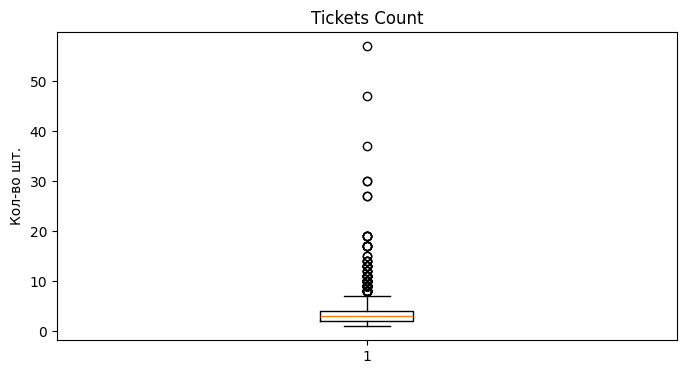

In [101]:
# Посмотрим на распределение в tickets_count
plt.figure(figsize=(8, 4))
plt.boxplot(new_df['tickets_count'])
plt.title('Tickets Count')
plt.ylabel('Кол-во шт.')
plt.show()

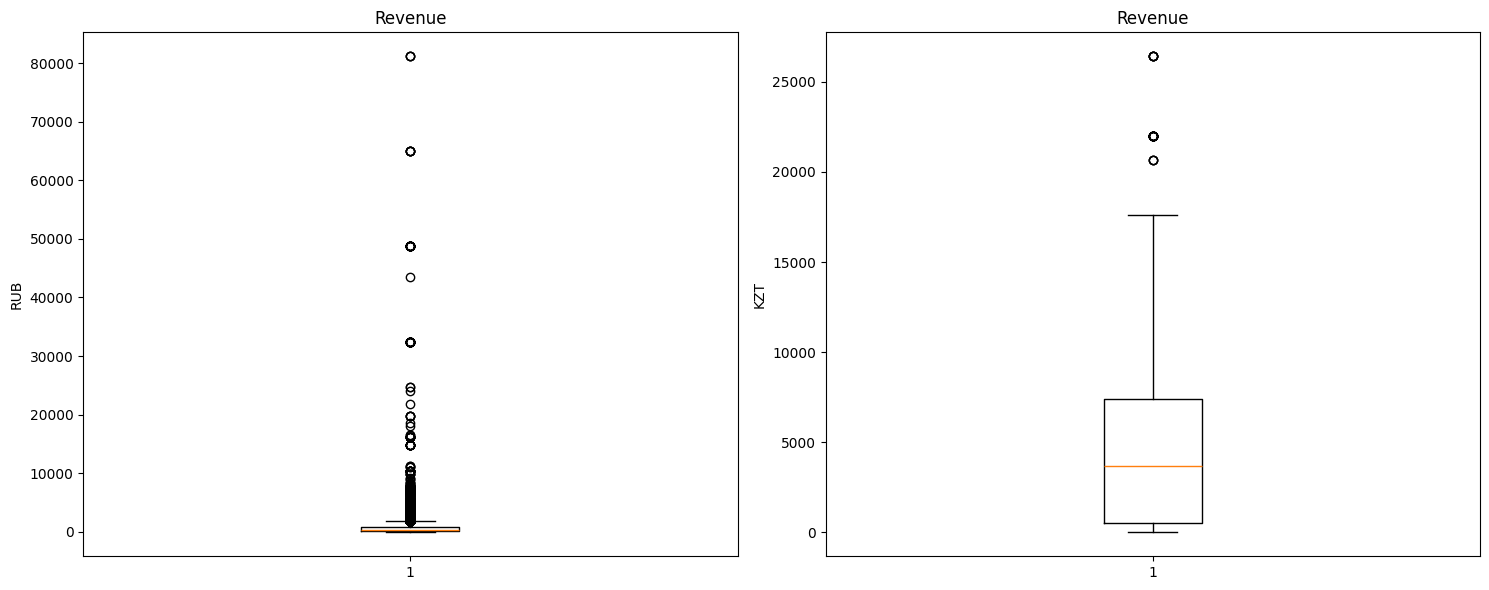

In [102]:
# # Посмотрим на распределение для revenue в разрезе валют
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Revenue по валютам
rub_data = new_df[new_df['currency_code'] == 'rub']['revenue']
kzt_data = new_df[new_df['currency_code'] == 'kzt']['revenue']

axes[0].boxplot(rub_data)
axes[0].set_title('Revenue')
axes[0].set_ylabel('RUB')

axes[1].boxplot(kzt_data)
axes[1].set_title('Revenue')
axes[1].set_ylabel('KZT')

# Смотрим
plt.tight_layout()
plt.show()

- Наибольший разброс наблюдается в рублёвых значениях.
- Напишем функцию для фильтрации отрицательных значений и 99-го процентиля

In [103]:
# Расчет 99 процентиля для revenue по разным валютам
rub_99_percentile = new_df[new_df['currency_code'] == 'rub']['revenue'].quantile(0.99)
kzt_99_percentile = new_df[new_df['currency_code'] == 'kzt']['revenue'].quantile(0.99)

print(f"99-й процентиль для RUB: {rub_99_percentile}")
print(f"99-й процентиль для KZT: {kzt_99_percentile}")

# Фильтрация выбросов
original_count = len(new_df)

# Для RUB
rub_mask = (new_df['currency_code'] == 'rub') & (new_df['revenue'] <= rub_99_percentile) & (new_df['revenue'] > 0)
# Для KZT
kzt_mask = (new_df['currency_code'] == 'kzt') & (new_df['revenue'] <= kzt_99_percentile) & (new_df['revenue'] > 0)

# Объединяем маски
filtered_df = new_df[rub_mask | kzt_mask]

print(f"Удалено записей: {original_count - len(filtered_df)}")
print(f"Процент удаленных: {(original_count - len(filtered_df)) / original_count * 100:.2f}%")

99-й процентиль для RUB: 2570.8
99-й процентиль для KZT: 17617.24
Удалено записей: 8736
Процент удаленных: 3.01%


#### Обработка дубликатов

In [104]:
# Проверка явных дубликатов
print(f"\nЯвных дубликатов: {filtered_df.duplicated().sum()}")


Явных дубликатов: 0


In [105]:
# Создаём список полей для проверки неявных дубликатов
duplicate_columns = ['user_id', 'created_ts_msk', 'event_id', 'venue_id', 'tickets_count', 'total']

# Поиск
potential_duplicates = filtered_df.duplicated(subset=duplicate_columns, keep=False)
print(f"Потенциальных неявных дубликатов: {potential_duplicates.sum()}")

Потенциальных неявных дубликатов: 79


In [106]:
# Визуальный осмотр
if potential_duplicates.sum() > 0:
    duplicate_samples = filtered_df[potential_duplicates].sort_values(by=duplicate_columns)
    
# Смотрим    
display(duplicate_samples)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season
11759,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,Светополянский округ,Глиноград,54,4443,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50",69.82,69.820000,8,лето
11760,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,Светополянский округ,Глиноград,54,4443,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50",69.82,69.820000,8,лето
26868,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,Каменевский регион,Глиногорск,213,2704,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43",1556.05,518.683333,7,лето
26870,1930763,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,Каменевский регион,Глиногорск,213,2704,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43",1556.05,518.683333,7,лето
51572,5378312,1f49b8de206b285,2024-10-01,2024-10-01 11:32:40,574431,нет,0,rub,desktop,155.99,...,Медовская область,Радужсвет,47,2157,"Студия дизайна ""Платформа"" Инкорпорэйтед","наб. Магистральная, д. 5",155.99,38.997500,10,осень
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285375,8547809,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,989.57,...,Каменевский регион,Глиногорск,213,4017,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",989.57,329.856667,6,лето
285382,8548099,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,989.57,...,Каменевский регион,Глиногорск,213,4017,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",989.57,329.856667,6,лето
285377,8547983,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,...,Каменевский регион,Глиногорск,213,4017,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",1319.43,329.857500,6,лето
285378,8548012,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,...,Каменевский регион,Глиногорск,213,4017,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",1319.43,329.857500,6,лето


- Визуальный осмотр показал, что неявные дубликаты дублируют информацию и ценности для исследования не представляют. Их соит удалить.

In [107]:
# Пишем функцию для удаления
def remove_implicit_duplicates(df, columns):
    """
    Удаляет неявные дубликаты, оставляя только первую запись.
    """
    # Удаляем дубликаты отсатвляя первую запись
    cleaned_df = df.drop_duplicates(
        subset=columns, 
        keep='first',     
        inplace=False      
    )
    
    # Обновляем индексы
    cleaned_df.reset_index(drop=True, inplace=True)
    
    return cleaned_df

# Запускаем функцию
duplicate_columns = ['user_id', 'created_ts_msk', 'event_id', 'venue_id', 'tickets_count', 'total']
final_df = remove_implicit_duplicates(filtered_df, duplicate_columns)

### Итоги предобрабоки и итоговый датафрейм

In [108]:
# Смторим
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281834 entries, 0 to 281833
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                281834 non-null  int64         
 1   user_id                 281834 non-null  object        
 2   created_dt_msk          281834 non-null  datetime64[ns]
 3   created_ts_msk          281834 non-null  datetime64[ns]
 4   event_id                281834 non-null  int64         
 5   cinema_circuit          281834 non-null  object        
 6   age_limit               281834 non-null  int8          
 7   currency_code           281834 non-null  object        
 8   device_type_canonical   281834 non-null  object        
 9   revenue                 281834 non-null  float64       
 10  service_name            281834 non-null  object        
 11  tickets_count           281834 non-null  int8          
 12  total                   281834

In [109]:
# Визуальный осмотр
final_df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",1521.94,380.4850,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,Каменевский регион,Глиногорск,213,2941,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",289.45,144.7250,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,Каменевский регион,Глиногорск,213,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",1258.57,314.6425,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,Североярская область,Озёрск,2,3574,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",8.49,4.2450,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,Озернинский край,Родниковецк,240,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",1390.41,463.4700,10,осень


In [110]:
# Статистика
final_df.describe()

,order_id,created_dt_msk,created_ts_msk,event_id,age_limit,revenue,tickets_count,total,days_since_prev,city_id,venue_id,revenue_rub,one_ticket_revenue_rub,month
count,2.818340e+05,281834,281834,281834.000000,281834.000000,281834.000000,281834.000000,281834.000000,260460.000000,281834.000000,281834.000000,281834.000000,281834.000000,281834.000000
mean,4.326933e+06,2024-09-02 18:48:27.907491328,2024-09-03 09:44:44.575842560,435889.332479,10.169341,599.908445,2.743842,7355.627310,3.249121,904.115295,2694.983756,516.861078,190.255282,8.579078
min,1.000000e+00,2024-06-01 00:00:00,2024-06-01 00:00:42,4436.000000,0.000000,0.020000,1.000000,0.930000,0.000000,2.000000,894.000000,0.020000,0.020000,6.000000
25%,2.169324e+06,2024-07-31 00:00:00,2024-07-31 19:58:03.500000,355361.000000,6.000000,125.690000,2.000000,2281.470000,0.000000,39.000000,1695.000000,121.042500,49.696250,7.000000
50%,4.327656e+06,2024-09-13 00:00:00,2024-09-13 15:34:33.500000,494565.000000,12.000000,362.425000,3.000000,4866.220000,0.000000,67.000000,2704.000000,349.440000,148.945000,9.000000
75%,6.488599e+06,2024-10-10 00:00:00,2024-10-10 06:35:33.500000,544944.000000,16.000000,805.455000,3.000000,8940.750000,1.000000,213.000000,3692.000000,784.120000,300.845000,10.000000
max,8.653108e+06,2024-10-31 00:00:00,2024-10-31 23:59:54,592325.000000,18.000000,17617.240000,47.000000,287172.100000,148.000000,37172.000000,4677.000000,2570.800000,2438.270000,10.000000
std,2.495795e+06,NaN,NaN,148083.498914,6.506684,991.952179,1.156558,13596.748922,11.417236,3474.674587,1089.778973,498.439338,162.278819,1.384012


**Итоги предобработки:**
- Для удобства дальнейшего анализа данные были объеденены в один датафрейм.
- Было произведено преобразование и оптимизация типов двнных в столбцах.
- Созданы новые столбцы.
- Обработаны анамальные значения в данных.
- Удалены дубликаты.

## 3. Исcледовательский анализ

### Анализ распределения заказов по сегментам и их сезонные изменения

#### Общее кол-во заказов по месяцам

In [111]:
# Определяем кол-во месяцев
print(f"Период данных: от {final_df['created_dt_msk'].min()} до {final_df['created_dt_msk'].max()}")

Период данных: от 2024-06-01 00:00:00 до 2024-10-31 00:00:00


- В данныз представлен срез с июня по октябрь.

In [112]:
# Группируем данные по месяцам
monthly_orders = final_df.groupby('month').agg(
    order_count=('order_id', 'count'),
    unique_users=('user_id', 'nunique')
).reset_index()

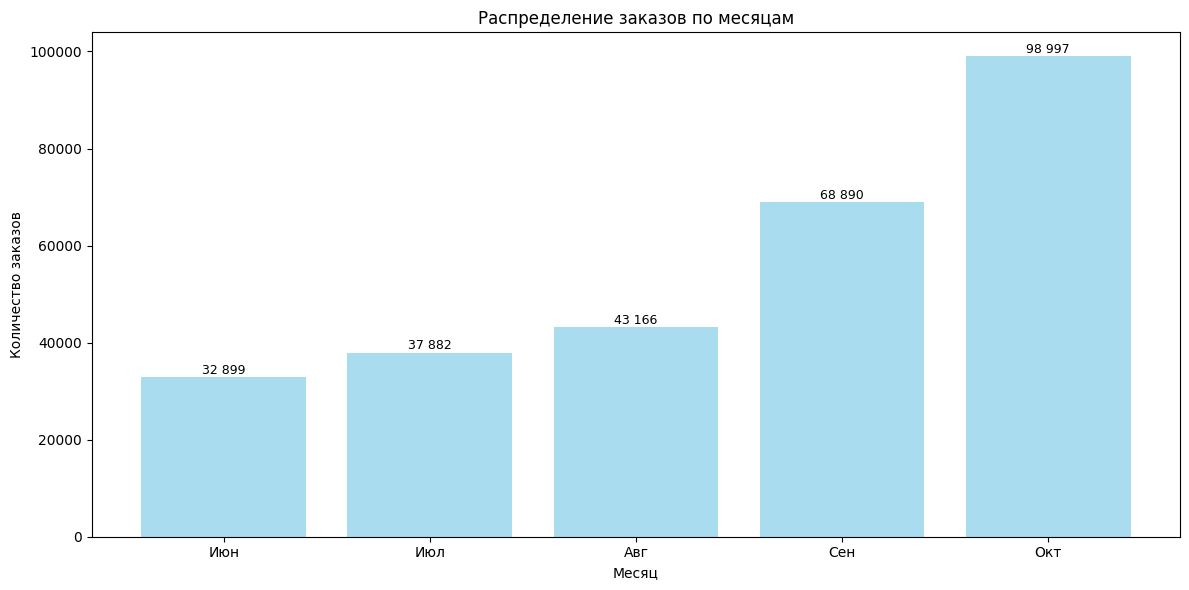

In [113]:
# Строим визуализацию
fig, ax = plt.subplots(figsize=(12, 6))

# Создаем список месяцев для корректного отображения
available_months = sorted(final_df['month'].unique())
month_labels_dict = {
    6: 'Июн', 7: 'Июл', 8: 'Авг', 9: 'Сен', 10: 'Окт'
}

month_labels = [month_labels_dict[m] for m in available_months]

bars = ax.bar(range(len(available_months)), monthly_orders['order_count'], 
              color='skyblue', alpha=0.7)

ax.set_xlabel('Месяц')
ax.set_ylabel('Количество заказов')
ax.set_title('Распределение заказов по месяцам')
ax.set_xticks(range(len(available_months)))
ax.set_xticklabels(month_labels)

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 100,
                f'{int(height):,}'.replace(',', ' '),
                ha='center', va='bottom', fontsize=9)

# Смотрим
plt.tight_layout()
plt.show()

In [114]:
# Считаем разницу
if len(available_months) >= 2:
    first_month = min(available_months)
    last_month = max(available_months)
    
    first_orders = monthly_orders[monthly_orders['month'] == first_month]['order_count'].values[0]
    last_orders = monthly_orders[monthly_orders['month'] == last_month]['order_count'].values[0]
    
    growth_percent = ((last_orders - first_orders) / first_orders) * 100 if first_orders > 0 else 0
    
    print(f"{month_labels_dict[first_month]}: {first_orders:,} заказов")
    print(f"{month_labels_dict[last_month]}: {last_orders:,} заказов")
    print(f"Рост заказов на {growth_percent:.1f}%")

Июн: 32,899 заказов
Окт: 98,997 заказов
Рост заказов на 200.9%


- Наблюдается ярковыраженный рост заказов с Июня по Октябрь.

#### Анализ сезонного распределения заказов

In [115]:
# Определение сезонов
summer_months = [6, 7, 8]  # лето
autumn_months = [9, 10, 11]  # осень

# Определение месяцев в сезоне
summer_months = [m for m in summer_months if m in available_months]
autumn_months = [m for m in autumn_months if m in available_months]

print(f"\nЛетние месяцы в данных: {[month_labels_dict[m] for m in summer_months]}")
print(f"Осенние месяцы в данных: {[month_labels_dict[m] for m in autumn_months]}")

if summer_months:
    summer_data = final_df[final_df['month'].isin(summer_months)]
    print(f"Летние заказы: {len(summer_data):,}")

if autumn_months:
    autumn_data = final_df[final_df['month'].isin(autumn_months)]
    print(f"Осенние заказы: {len(autumn_data):,}")


Летние месяцы в данных: ['Июн', 'Июл', 'Авг']
Осенние месяцы в данных: ['Сен', 'Окт']
Летние заказы: 113,947
Осенние заказы: 167,887


- Видим, что за два осенних месяца было совершено больше заказов, чем за всё лето.

In [116]:
# Напишем функция для анализа распределения по категориям
def analyze_seasonal_distribution(season_data, season_name, category_col):
    if len(season_data) == 0:
        return pd.DataFrame()
    dist = season_data[category_col].value_counts(normalize=True).reset_index()
    dist.columns = [category_col, 'percentage']
    dist['season'] = season_name
    dist['percentage'] = dist['percentage'] * 100
    return dist

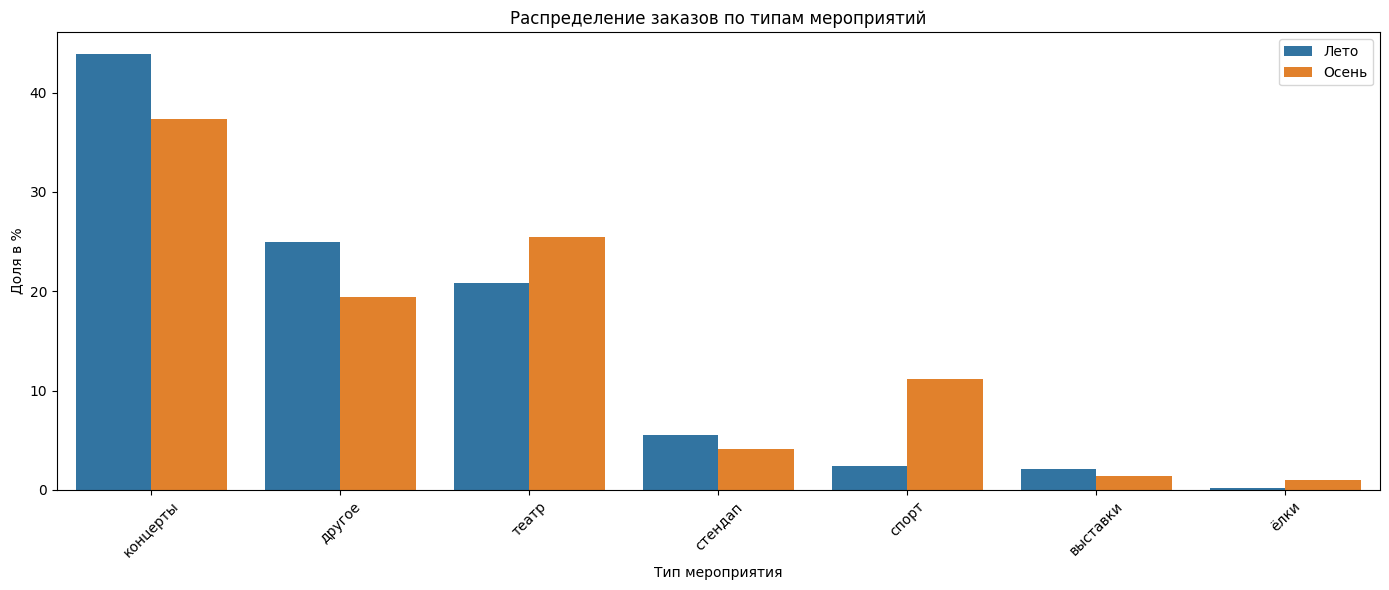

In [117]:
# Расппределение по типам мероприятий
if len(summer_data) > 0 and len(autumn_data) > 0:  # только если есть данные за оба сезона
    event_type_summer = analyze_seasonal_distribution(summer_data, 'Лето', 'event_type_main')
    event_type_autumn = analyze_seasonal_distribution(autumn_data, 'Осень', 'event_type_main')
    event_type_comparison = pd.concat([event_type_summer, event_type_autumn])

    # Визуализация
    fig, ax = plt.subplots(figsize=(14, 6))
    
    if len(event_type_comparison) > 0:
        sns.barplot(data=event_type_comparison, x='event_type_main', y='percentage', 
                    hue='season', ax=ax)
        ax.set_title('Распределение заказов по типам мероприятий')
        ax.set_xlabel('Тип мероприятия')
        ax.set_ylabel('Доля в %')
        ax.tick_params(axis='x', rotation=45)
        ax.legend()
    
    plt.tight_layout()
    plt.show()

- Только категории `театр` и `спорт` осенью превышают летние значения. У остальных категориях летом доля заказов выше.

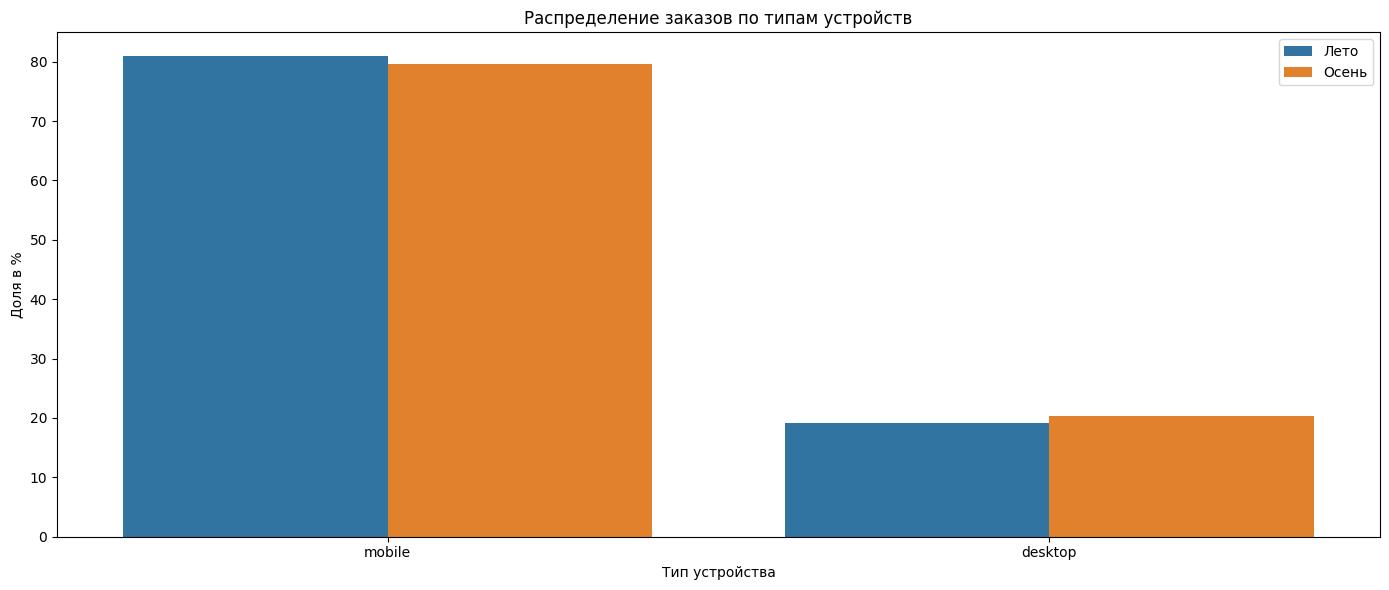

In [118]:
# Расппределение по типам устройств
if len(summer_data) > 0 and len(autumn_data) > 0:  # только если есть данные за оба сезона
    device_type_summer = analyze_seasonal_distribution(summer_data, 'Лето', 'device_type_canonical')
    device_type_autumn = analyze_seasonal_distribution(autumn_data, 'Осень', 'device_type_canonical')
    device_type_comparison = pd.concat([device_type_summer, device_type_autumn])

    # Визуализация
    fig, ax = plt.subplots(figsize=(14, 6))
    
    if len(device_type_comparison) > 0:
        sns.barplot(data=device_type_comparison, x='device_type_canonical', y='percentage', 
                    hue='season', ax=ax)
        ax.set_title('Распределение заказов по типам устройств')
        ax.set_xlabel('Тип устройства')
        ax.set_ylabel('Доля в %')
        ax.legend()
    
    plt.tight_layout()
    plt.show()

- Доля пользователей мобильного приложения летом превалирует в заказах. В десктопной версии, наоборот.

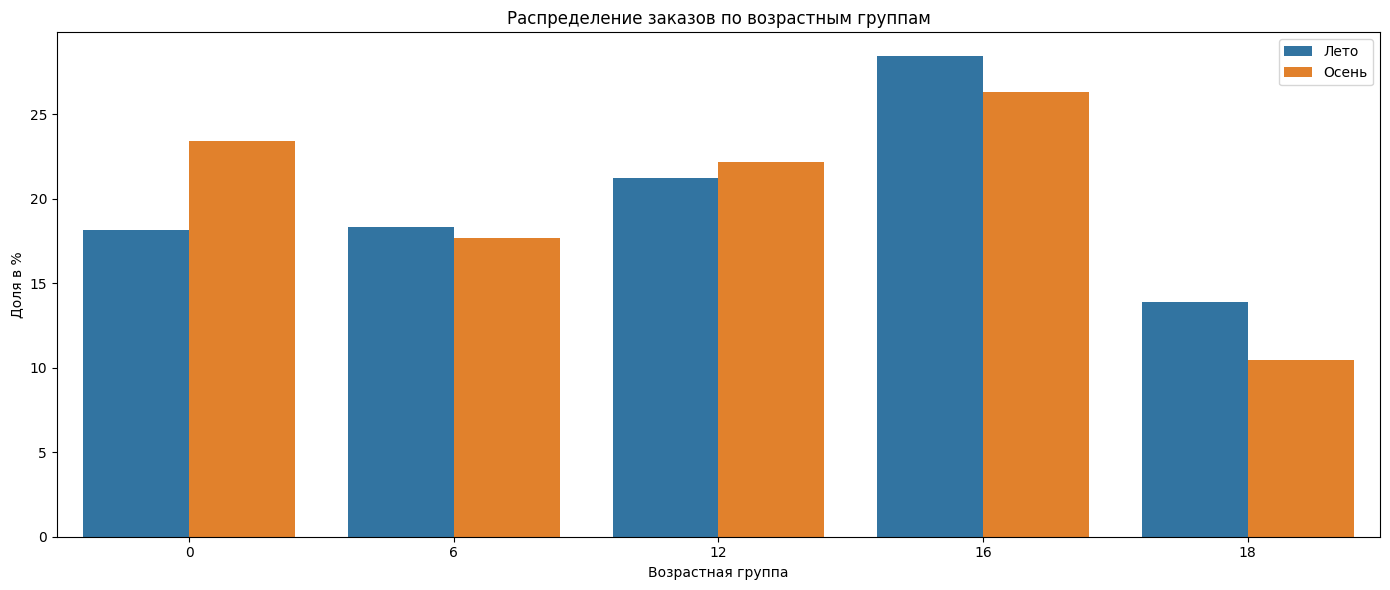

In [119]:
# Расппределение по возрастным группам
if len(summer_data) > 0 and len(autumn_data) > 0:  # только если есть данные за оба сезона
    age_limit_summer = analyze_seasonal_distribution(summer_data, 'Лето', 'age_limit')
    age_limit_autumn = analyze_seasonal_distribution(autumn_data, 'Осень', 'age_limit')
    age_limit_comparison = pd.concat([age_limit_summer, age_limit_autumn])

    # Визуализация
    fig, ax = plt.subplots(figsize=(14, 6))
    
    if len(age_limit_comparison) > 0:
        sns.barplot(data=age_limit_comparison, x='age_limit', y='percentage', 
                    hue='season', ax=ax)
        ax.set_title('Распределение заказов по возрастным группам')
        ax.set_xlabel('Возрастная группа')
        ax.set_ylabel('Доля в %')
        ax.legend()
    
    plt.tight_layout()
    plt.show()

- Доля заказов с возрастным ограничением `16+` составлет более четверти всех заказов. Летом этот показатель ещё выше.

#### Анализ изменения выручки с продажи одного билета

In [120]:
# Готовим данные для визуализаций
if len(summer_data) > 0 and len(autumn_data) > 0: # только если есть данные за оба сезона
    # Расчет средней стоимости билета по типам мероприятий
    summer_ticket_prices = summer_data.groupby('event_type_main').agg(
        avg_ticket_price=('one_ticket_revenue_rub', 'mean'),
        order_count=('order_id', 'count')
    ).reset_index()
    summer_ticket_prices['season'] = 'Лето'

    autumn_ticket_prices = autumn_data.groupby('event_type_main').agg(
        avg_ticket_price=('one_ticket_revenue_rub', 'mean'),
        order_count=('order_id', 'count')
    ).reset_index()
    autumn_ticket_prices['season'] = 'Осень'

    # Объединяем данные
    ticket_prices_comparison = pd.merge(
        summer_ticket_prices, 
        autumn_ticket_prices, 
        on='event_type_main', 
        suffixes=('_summer', '_autumn'),
        how='inner'
    )

    # Расчет относительного изменения
    ticket_prices_comparison['price_change_percent'] = (
        (ticket_prices_comparison['avg_ticket_price_autumn'] - 
         ticket_prices_comparison['avg_ticket_price_summer']) / 
        ticket_prices_comparison['avg_ticket_price_summer'] * 100
    )

    # Добавим фильтрацию типов мероприятий с достаточным количеством заказов(на всякий случай)
    min_orders = 1
    valid_events = ticket_prices_comparison[
        (ticket_prices_comparison['order_count_summer'] >= min_orders) & 
        (ticket_prices_comparison['order_count_autumn'] >= min_orders)]

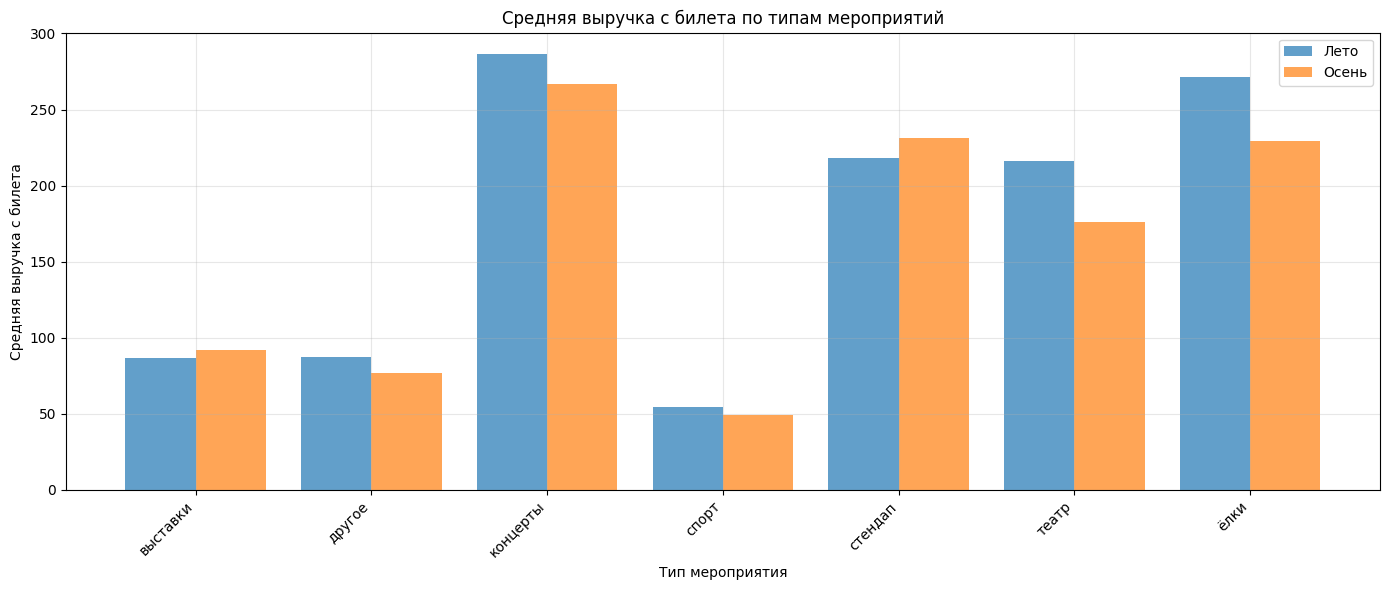

In [121]:
# Создаём график
fig, ax1 = plt.subplots(figsize=(14, 6))
    
x_positions = range(len(valid_events))
    
# Построение столбцов для летних и осенних цен
summer_bars = ax1.bar(x_positions, 
                        valid_events['avg_ticket_price_summer'], 
                        alpha=0.7, label='Лето', width=0.4)
autumn_bars = ax1.bar([x + 0.4 for x in x_positions], 
                        valid_events['avg_ticket_price_autumn'], 
                        alpha=0.7, label='Осень', width=0.4)
    
# Настройка подписей и оформления
ax1.set_xlabel('Тип мероприятия')
ax1.set_ylabel('Средняя выручка с билета')
ax1.set_title('Средняя выручка с билета по типам мероприятий')
ax1.set_xticks([x + 0.2 for x in x_positions])
ax1.set_xticklabels(valid_events['event_type_main'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Смотрим
plt.tight_layout()
plt.show()

- Спорт имеет самую низкую выручку с одного билета, в отличии от концертов. Вне зависимости от сезона.

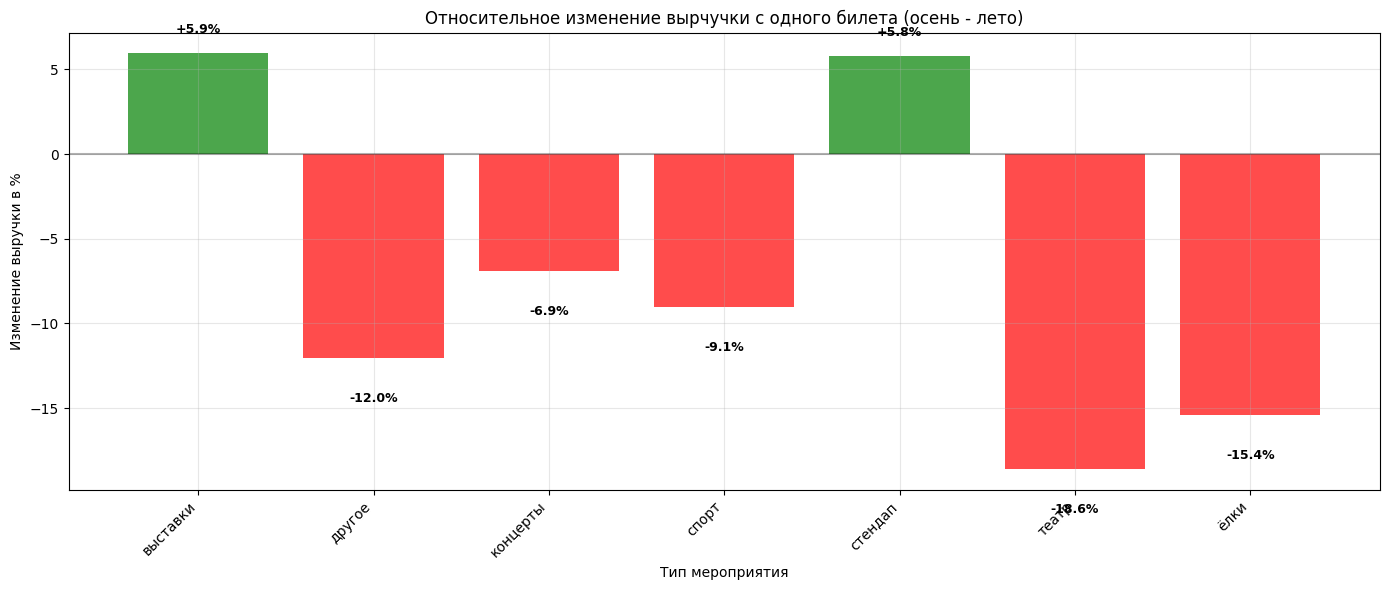

In [122]:
# Создание подграфика для относительных изменений
fig, ax2 = plt.subplots(figsize=(14, 6))
    
x_positions = range(len(valid_events))
    
# Цвета столбцов
colors = ['green' if x >= 0 else 'red' for x in valid_events['price_change_percent']]
    
# Построение столбцов с изменениями
bars = ax2.bar(x_positions, valid_events['price_change_percent'], 
                color=colors, alpha=0.7)
    
# Настройка подписей
ax2.set_xlabel('Тип мероприятия')
ax2.set_ylabel('Изменение выручки в %')
ax2.set_title('Относительное изменение вырчучки с одного билета (осень - лето)')
ax2.set_xticks(x_positions)
ax2.set_xticklabels(valid_events['event_type_main'], rotation=45, ha='right')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.grid(True, alpha=0.3)
    
# Добавление значений на график
for i, (bar, change) in enumerate(zip(bars, valid_events['price_change_percent'])):
    ax2.text(bar.get_x() + bar.get_width()/2., 
                bar.get_height() + (1 if change >=0 else -2),
                f'{change:+.1f}%', 
                ha='center', 
                va='bottom' if change >=0 else 'top', 
                fontsize=9, 
                fontweight='bold')
    
plt.tight_layout()
plt.show()

- Только в двух категорях мероприятий `выставки` и `стендап` выручка с олного билета выросла осенью. В остальных, ярковыраженный тренд на снижение.

**Промежуточный вывод**
- С наступлением осени общее кол-во заказов растет.
- Доля мероприятий типа: `концерт` и `другое` летом выше. В остальных типах меропрятий, доля осенью выше.
- Средняя выручка с одного билета летом выше во всех категорях мероприятий, кроме`выставки` и `стендап`, в них выручка с олного билета выросла осенью.
- Только категории `театр` и `спорт` осенью превышают летние значения. У остальных категориях летом доля заказов выше.
- Спорт имеет самую низкую выручку с одного билета, в отличии от концертов. Вне зависимости от сезона.
- Доля заказов с возрастным ограничением `16+` составлет более четверти всех заказов. Летом этот показатель ещё выше.
- Доля пользователей мобильного приложения летом превалирует в заказах. В десктопной версии, наоборот.

### Осенняя активность пользователей


#### Динамика изменений по дням

In [123]:
# Фильтруем данные за осенние месяцы
autumn_data = final_df[final_df['month'].isin([9, 10])].copy()

# Создаем столбец с датой и днем недели
autumn_data['date'] = autumn_data['created_dt_msk'].dt.date
autumn_data['day_of_week'] = autumn_data['created_dt_msk'].dt.day_name()
autumn_data['day_of_week_num'] = autumn_data['created_dt_msk'].dt.dayofweek

# Создаем сводную таблицу по дням
daily_metrics = autumn_data.groupby('date').agg(
    total_orders=('order_id', 'count'),
    unique_users=('user_id', 'nunique'),
    total_revenue=('revenue_rub', 'sum'),
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')
).reset_index()

# Рассчитываем дополнительные метрики
daily_metrics['orders_per_user'] = daily_metrics['total_orders'] / daily_metrics['unique_users']
daily_metrics['day_of_week'] = pd.to_datetime(daily_metrics['date']).dt.day_name()
daily_metrics['day_of_week_num'] = pd.to_datetime(daily_metrics['date']).dt.dayofweek
daily_metrics['is_weekend'] = daily_metrics['day_of_week_num'].isin([5, 6])  # 5=суббота, 6=воскресенье

print(f"Количество дней в анализе: {len(daily_metrics)}")
print(f"Дни недели в данных: {sorted(daily_metrics['day_of_week'].unique())}")

Количество дней в анализе: 61
Дни недели в данных: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']


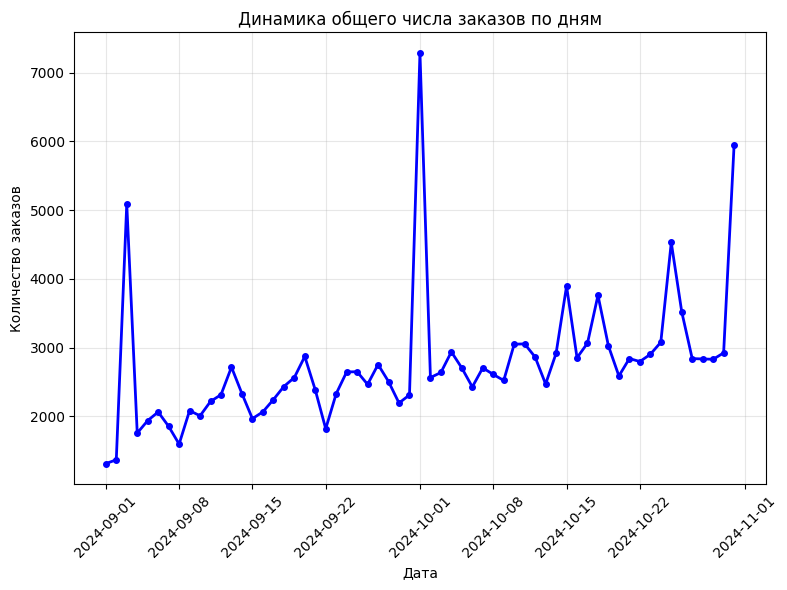

In [124]:
# Общее число заказов
plt.figure(figsize=(8, 6))
plt.plot(daily_metrics['date'], daily_metrics['total_orders'], 
         marker='o', linewidth=2, markersize=4, color='blue')
plt.title('Динамика общего числа заказов по дням')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

- Наблюдаем рост общего кол-ва заказов от неделе к неделе.

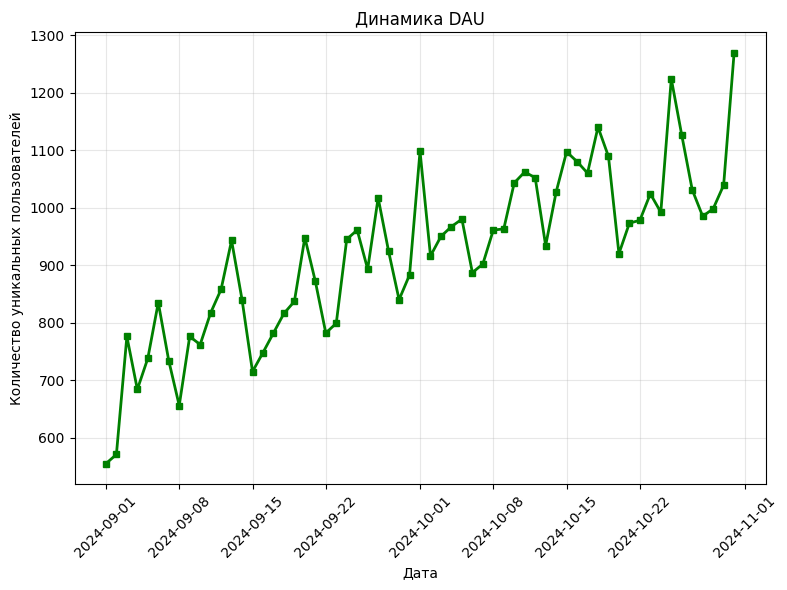

In [125]:
# Количество активных пользователей (DAU)
plt.figure(figsize=(8, 6))
plt.plot(daily_metrics['date'], daily_metrics['unique_users'], 
         marker='s', linewidth=2, markersize=4, color='green')
plt.title('Динамика DAU')
plt.xlabel('Дата')
plt.ylabel('Количество уникальных пользователей')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

- Динамика DAU растет в неделе к неделе.

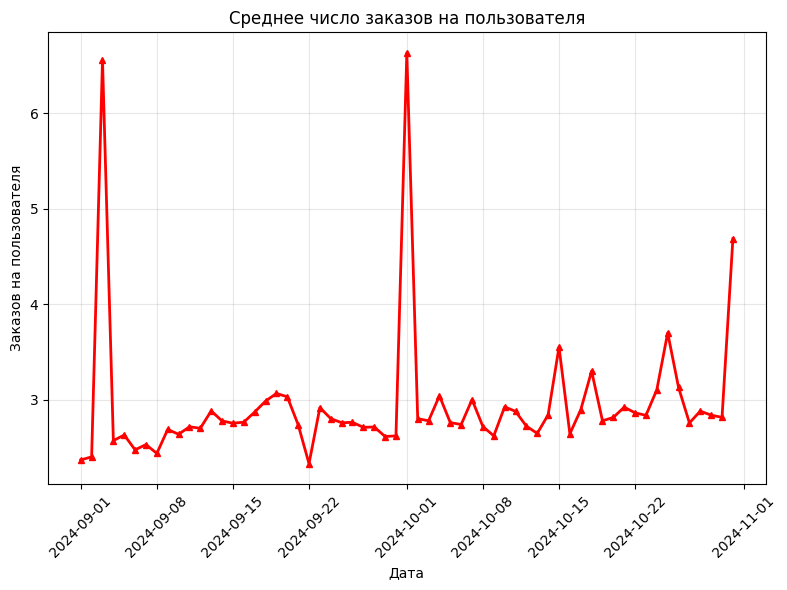

In [126]:
# Среднее число заказов на пользователя
plt.figure(figsize=(8, 6))
plt.plot(daily_metrics['date'], daily_metrics['orders_per_user'], 
         marker='^', linewidth=2, markersize=4, color='red')
plt.title('Среднее число заказов на пользователя')
plt.xlabel('Дата')
plt.ylabel('Заказов на пользователя')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

- Среднее число заказов имеет положительную динамику с всплесками активности в начале/конце месяца.

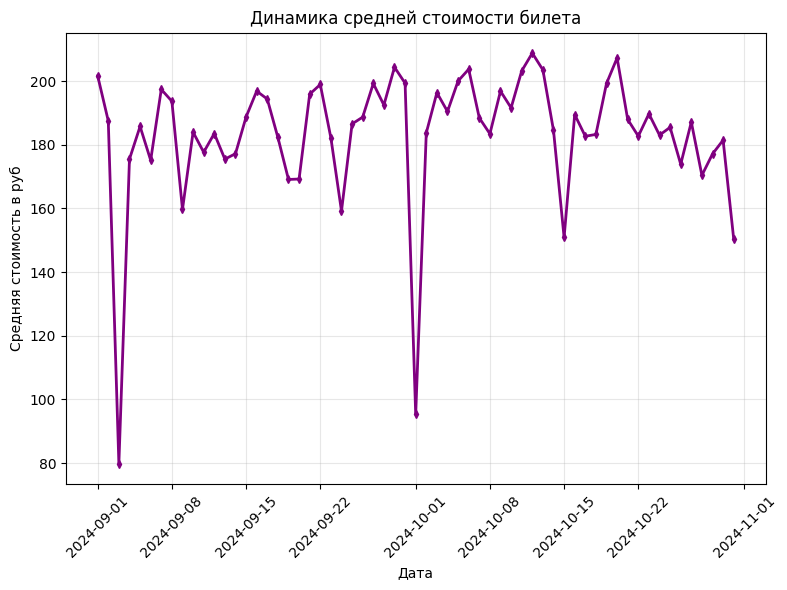

In [127]:
# Средняя стоимость билета
plt.figure(figsize=(8, 6))
plt.plot(daily_metrics['date'], daily_metrics['avg_ticket_price'], 
         marker='d', linewidth=2, markersize=4, color='purple')
plt.title('Динамика средней стоимости билета')
plt.xlabel('Дата')
plt.ylabel('Средняя стоимость в руб')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

- Динамика средней цены не имеет ярковыраженного тренда и находится в корридоре от `~160` до `~200` 

#### Анализ недельной цикличности

In [128]:
# Анализ недельной цикличности
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

# Агрегация по дням недели
weekly_pattern = daily_metrics.groupby(['day_of_week_num', 'day_of_week']).agg({
    'total_orders': 'mean',
    'unique_users': 'mean',
    'orders_per_user': 'mean',
    'avg_ticket_price': 'mean'
}).reset_index().sort_values('day_of_week_num')

# Переименовываем для удобства
weekly_pattern.columns = ['day_num', 'day_name', 'avg_orders', 'avg_users', 'avg_orders_per_user', 'avg_ticket_price']

# Сравнение будни и выходные
weekday_data = daily_metrics[~daily_metrics['is_weekend']]
weekend_data = daily_metrics[daily_metrics['is_weekend']]

# Средние значения
weekday_stats = weekday_data[['total_orders', 'unique_users', 'orders_per_user', 'avg_ticket_price']].mean()
weekend_stats = weekend_data[['total_orders', 'unique_users', 'orders_per_user', 'avg_ticket_price']].mean()

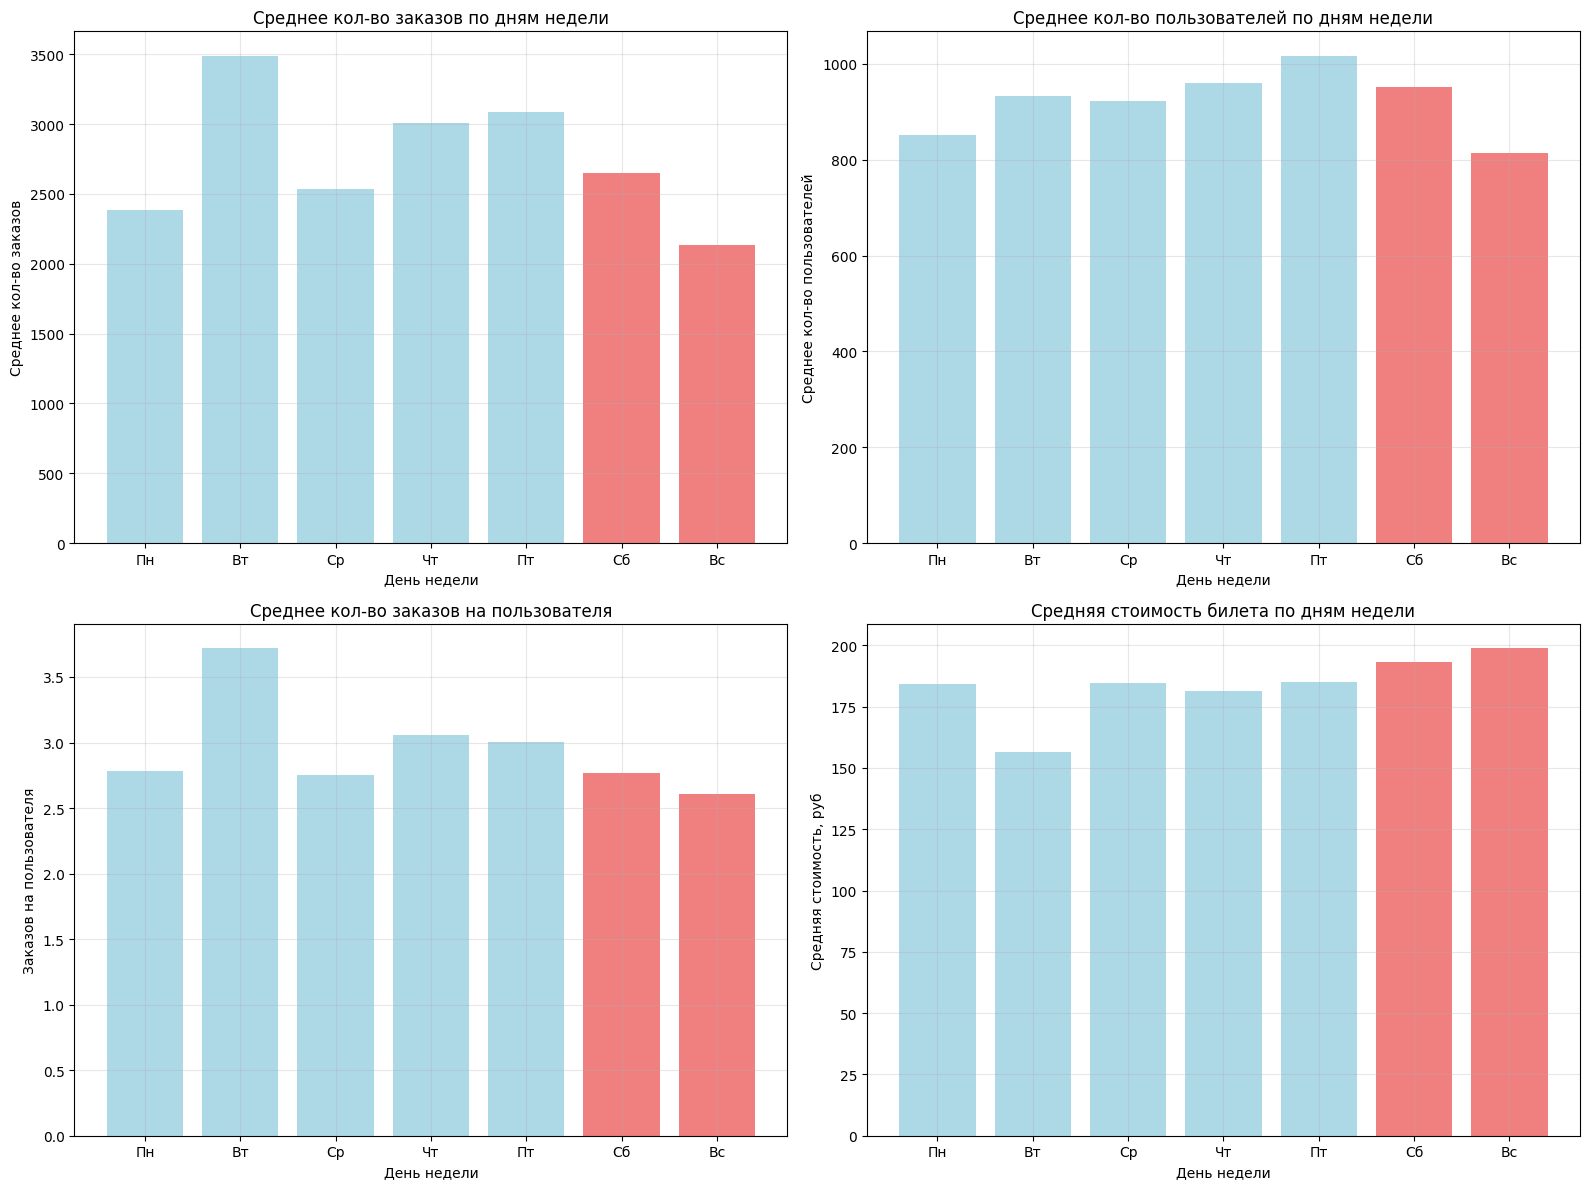

In [129]:
# Визуализации
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Среднее количество заказов по дням недели
ax1.bar(weekly_pattern['day_num'], weekly_pattern['avg_orders'], 
        color=['lightblue' if x < 5 else 'lightcoral' for x in weekly_pattern['day_num']])
ax1.set_title('Среднее кол-во заказов по дням недели')
ax1.set_xlabel('День недели')
ax1.set_ylabel('Среднее кол-во заказов')
ax1.set_xticks(weekly_pattern['day_num'])
ax1.set_xticklabels(weekday_labels)
ax1.grid(True, alpha=0.3)

# Среднее количество пользователей по дням недели
ax2.bar(weekly_pattern['day_num'], weekly_pattern['avg_users'], 
        color=['lightblue' if x < 5 else 'lightcoral' for x in weekly_pattern['day_num']])
ax2.set_title('Среднее кол-во пользователей по дням недели')
ax2.set_xlabel('День недели')
ax2.set_ylabel('Среднее кол-во пользователей')
ax2.set_xticks(weekly_pattern['day_num'])
ax2.set_xticklabels(weekday_labels)
ax2.grid(True, alpha=0.3)

# Среднее количество заказов на пользователя
ax3.bar(weekly_pattern['day_num'], weekly_pattern['avg_orders_per_user'], 
        color=['lightblue' if x < 5 else 'lightcoral' for x in weekly_pattern['day_num']])
ax3.set_title('Среднее кол-во заказов на пользователя')
ax3.set_xlabel('День недели')
ax3.set_ylabel('Заказов на пользователя')
ax3.set_xticks(weekly_pattern['day_num'])
ax3.set_xticklabels(weekday_labels)
ax3.grid(True, alpha=0.3)

# Средняя стоимость билета по дням недели
ax4.bar(weekly_pattern['day_num'], weekly_pattern['avg_ticket_price'], 
        color=['lightblue' if x < 5 else 'lightcoral' for x in weekly_pattern['day_num']])
ax4.set_title('Средняя стоимость билета по дням недели')
ax4.set_xlabel('День недели')
ax4.set_ylabel('Средняя стоимость, руб')
ax4.set_xticks(weekly_pattern['day_num'])
ax4.set_xticklabels(weekday_labels)
ax4.grid(True, alpha=0.3)

# Смотрим
plt.tight_layout()
plt.show()

In [130]:
# Сравнениие средних значений
comparison_df = pd.DataFrame({
    'Будни': weekday_stats,
    'Выходные': weekend_stats,
    'Разница': weekend_stats - weekday_stats,
    'Разница в %': ((weekend_stats - weekday_stats) / weekday_stats) * 100
})
print(comparison_df.round(2))

                    Будни  Выходные  Разница  Разница в %
total_orders      2896.98   2377.65  -519.33       -17.93
unique_users       934.93    878.65   -56.28        -6.02
orders_per_user      3.06      2.68    -0.38       -12.45
avg_ticket_price   178.19    196.13    17.95        10.07


- Среднее кол-во заказов и заказов на одного пользователя по дням имеет ярковыраженную тенденцию во вторник.
- Среднее кол-во пользователей находится на пике с четверга по субботу.
- Средняя стоимость билетов в выходные выше.

**Промежуточный вывод:**
- Наблюдаем рост общего кол-ва заказов от неделе к неделе.
- Динамика DAU растет в неделе к неделе.
- Среднее число заказов имеет положительную динамику с всплесками активности в начале/конце месяца.
- Динамика средней цены не имеет ярковыраженного тренда и находится в корридоре от `~160` до `~200` 
- Среднее кол-во заказов и заказов на одного пользователя по дням имеет ярковыраженную тенденцию во вторник.
- Среднее кол-во пользователей находится на пике с четверга по субботу.
- Средняя стоимость билетов в выходные выше.

### Популярные события и партнёры

#### Анализ по регионам

In [131]:
# Готовим данные
# Группируем по регионам
region_analysis = final_df.groupby('region_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count'),
    total_revenue=('revenue_rub', 'sum'),
    unique_venues=('venue_id', 'nunique')
).reset_index().sort_values('unique_events', ascending=False)

# Рассчитываем доли
total_events = region_analysis['unique_events'].sum()
total_orders_all = region_analysis['total_orders'].sum()
region_analysis['events_share'] = (region_analysis['unique_events'] / total_events) * 100
region_analysis['orders_share'] = (region_analysis['total_orders'] / total_orders_all) * 100
region_analysis['avg_orders_per_event'] = region_analysis['total_orders'] / region_analysis['unique_events']

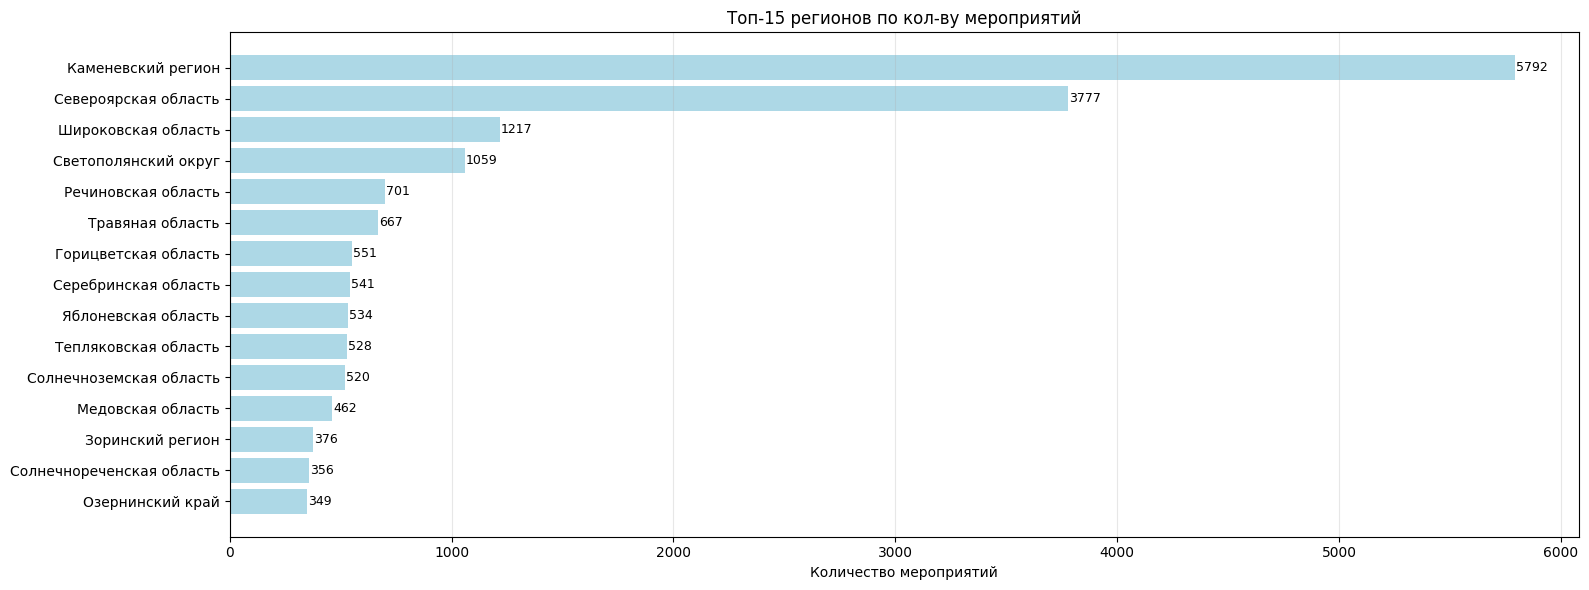

In [132]:
# Визуализация
fig, ax1 = plt.subplots(figsize=(16, 6))

# Колво мероприятий по регионам 
top_15_regions = region_analysis.head(15)
bars1 = ax1.barh(range(len(top_15_regions)), top_15_regions['unique_events'][::-1], 
                color='lightblue')
ax1.set_yticks(range(len(top_15_regions)))
ax1.set_yticklabels(top_15_regions['region_name'][::-1])
ax1.set_xlabel('Количество мероприятий')
ax1.set_title('Топ-15 регионов по кол-ву мероприятий')
ax1.grid(True, alpha=0.3, axis='x')

# Добавляем значения на столбцы
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 5, i, f'{int(width)}', va='center', fontsize=9)

# Смотрим
plt.tight_layout()
plt.show()

- Наблюдаем два ярковыраженных лидера, это: Каменевский район и Североярская область.

In [133]:
# Посчитаем доли
print(f"Всего регионов: {len(region_analysis)}")
print(f"Всего мероприятий: {total_events:,}")
print(f"Всего заказов: {total_orders_all:,}")

# Топ-10 регионов по кол-ву мероприятий
top_regions_events = region_analysis.head(10).copy()
top_regions_events['cumulative_share'] = top_regions_events['events_share'].cumsum()

print("\nТоп-10 регионов по кол-ву мероприятий:")
for i, row in top_regions_events.iterrows():
    print(f"{i+1:2d}. {row['region_name'][:30]:30s} {row['unique_events']:4d} мероприятий или{row['events_share']:5.1f}%")

Всего регионов: 81
Всего мероприятий: 22,007
Всего заказов: 281,834

Топ-10 регионов по кол-ву мероприятий:
24. Каменевский регион             5792 мероприятий или 26.3%
61. Североярская область           3777 мероприятий или 17.2%
78. Широковская область            1217 мероприятий или  5.5%
58. Светополянский округ           1059 мероприятий или  4.8%
53. Речиновская область             701 мероприятий или  3.2%
75. Травяная область                667 мероприятий или  3.0%
12. Горицветская область            551 мероприятий или  2.5%
62. Серебринская область            541 мероприятий или  2.5%
79. Яблоневская область             534 мероприятий или  2.4%
70. Тепляковская область            528 мероприятий или  2.4%


- Два лидера вместе имеют более чем 40% долю рынка.

#### Анализ по партнерам

In [134]:
# Подготовка данных
# Группируем
partner_analysis = final_df.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count'),
    total_revenue=('revenue_rub', 'sum'),
    avg_order_value=('revenue_rub', 'mean')
).reset_index().sort_values('total_orders', ascending=False)

# Рассчитываем доли
total_partners = len(partner_analysis)
partner_analysis['orders_share'] = (partner_analysis['total_orders'] / total_orders_all) * 100
partner_analysis['revenue_share'] = (partner_analysis['total_revenue'] / partner_analysis['total_revenue'].sum()) * 100
partner_analysis['events_share'] = (partner_analysis['unique_events'] / total_events) * 100

# Топ-10 партнеров
top_partners = partner_analysis.head(10).copy()
top_partners['cumulative_orders_share'] = top_partners['orders_share'].cumsum()
top_partners['cumulative_revenue_share'] = top_partners['revenue_share'].cumsum()

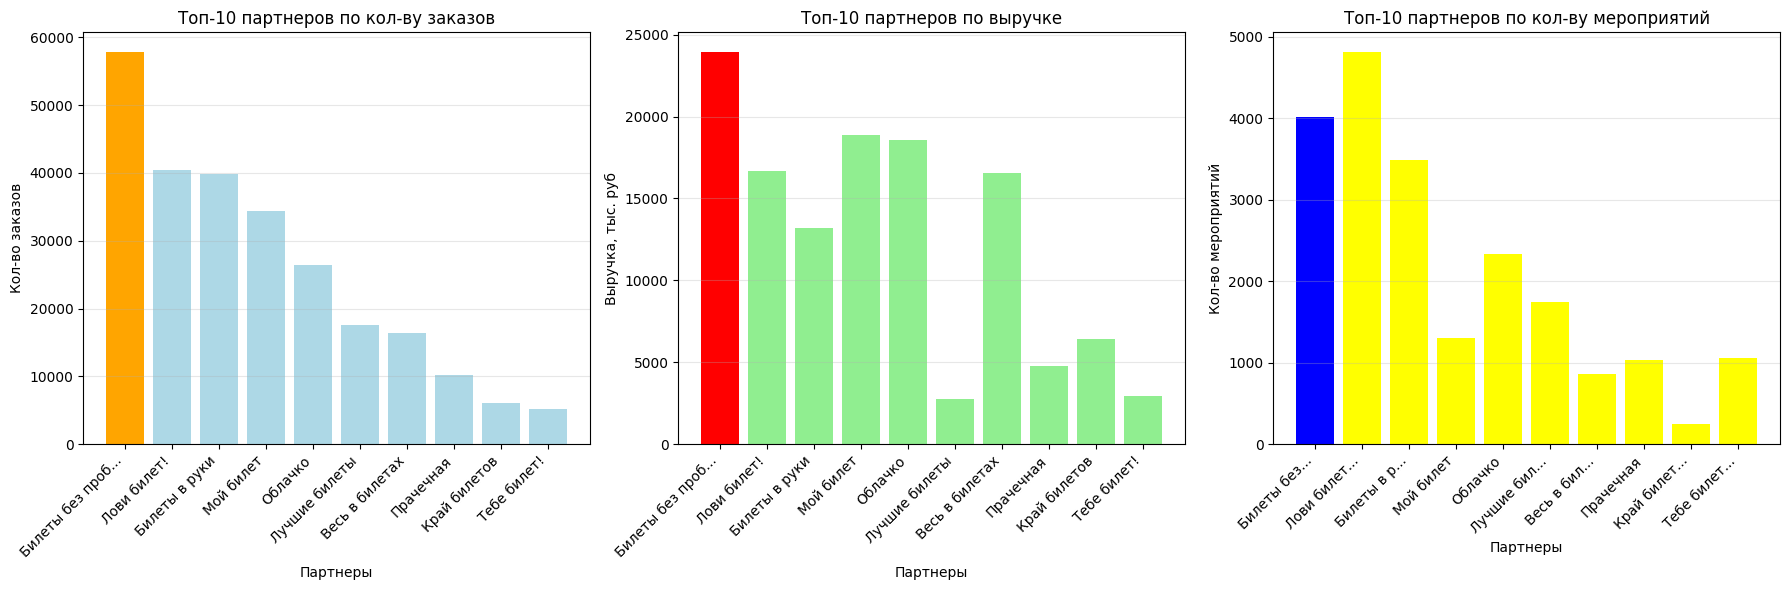

In [135]:
# Визуализация распределения по партнерам
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Кол-во заказов по партнерам
bars2 = ax1.bar(range(len(top_partners)), top_partners['total_orders'], 
               color=['lightblue' if i > 0 else 'orange' for i in range(len(top_partners))])
ax1.set_xlabel('Партнеры')
ax1.set_ylabel('Кол-во заказов')
ax1.set_title('Топ-10 партнеров по кол-ву заказов')
ax1.set_xticks(range(len(top_partners)))
ax1.set_xticklabels([name[:15] + '...' if len(name) > 15 else name for name in top_partners['service_name']], 
                   rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')

# Выручка по партнерам
bars3 = ax2.bar(range(len(top_partners)), top_partners['total_revenue']/1000, 
               color=['lightgreen' if i > 0 else 'red' for i in range(len(top_partners))])
ax2.set_xlabel('Партнеры')
ax2.set_ylabel('Выручка, тыс. руб')
ax2.set_title('Топ-10 партнеров по выручке')
ax2.set_xticks(range(len(top_partners)))
ax2.set_xticklabels([name[:15] + '...' if len(name) > 15 else name for name in top_partners['service_name']], 
                   rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

# Кол-во мероприятий по партнерам 
bars4 = ax3.bar(range(len(top_partners)), top_partners['unique_events'], 
                color=['yellow' if i > 0 else 'blue' for i in range(len(top_partners))])
ax3.set_xlabel('Партнеры')
ax3.set_ylabel('Кол-во мероприятий')
ax3.set_title('Топ-10 партнеров по кол-ву мероприятий')
ax3.set_xticks(range(len(top_partners)))
ax3.set_xticklabels([name[:10] + '...' if len(name) > 10 else name for name in top_partners['service_name']], 
                   rotation=45, ha='right')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [136]:
# Итого статистика по партнёрам
print("\nТоп-10 партнеров по количеству заказов:")
for i, row in top_partners.iterrows():
    print(f"{i+1:2d}. {row['service_name'][:25]:25s} {row['total_orders']:6d} заказов "
          f"({row['orders_share']:5.1f}%), {row['total_revenue']:,.0f} руб")


Топ-10 партнеров по количеству заказов:
 4. Билеты без проблем         57860 заказов ( 20.5%), 23,943,885 руб
22. Лови билет!                40503 заказов ( 14.4%), 16,673,895 руб
 6. Билеты в руки              39799 заказов ( 14.1%), 13,193,924 руб
25. Мой билет                  34426 заказов ( 12.2%), 18,887,652 руб
26. Облачко                    26402 заказов (  9.4%), 18,588,614 руб
23. Лучшие билеты              17619 заказов (  6.3%), 2,724,084 руб
 9. Весь в билетах             16424 заказов (  5.8%), 16,532,346 руб
27. Прачечная                  10222 заказов (  3.6%), 4,746,811 руб
20. Край билетов                6109 заказов (  2.2%), 6,405,689 руб
31. Тебе билет!                 5189 заказов (  1.8%), 2,962,309 руб


In [137]:
# Кличественные данные
print(f"Всего билетных партнеров: {total_partners}")
print(f"Общая выручка: {partner_analysis['total_revenue'].sum():,.0f} руб")

Всего билетных партнеров: 36
Общая выручка: 145,669,025 руб


**Промежуточный вывод:**
1. РАСПРЕДЕЛЕНИЕ ПО РЕГИОНАМ:
   - Каменевский регион значительно опережает другие регионы
   - Каменевский регион агрегирует 26.3% мероприятий
   - На топ-10 регионов приходится 69.8% всех мероприятий

2. РАСПРЕДЕЛЕНИЕ ПО ПАРТНЕРАМ:
   - Билеты без проблем - абсолютный лидер по заказам и выручке
   - Билеты без проблем обрабатывает 20.5% всех заказов
   - На топ-10 партнеров приходится 90.3% всех заказов

## 4. Статистический анализ данных

#### Готовим обобщённые данные

In [138]:
# Фильтруем данные за осенний период
autumn_data = final_df[final_df['month'].isin([9, 10])].copy()

# Распределение по типам устройств
device_distribution = autumn_data['device_type_canonical'].value_counts()
print("\nРаспределение заказов по типам устройств:")
for device, count in device_distribution.items():
    percentage = (count / len(autumn_data)) * 100
    print(f"  {device}: {count:,} заказов ({percentage:.1f}%)")

# Разделяем данные по типам устройств
mobile_data = autumn_data[autumn_data['device_type_canonical'] == 'mobile']
desktop_data = autumn_data[autumn_data['device_type_canonical'] == 'desktop']

# Группируем данные по устройствам
mobile_orders_per_user = mobile_data.groupby('user_id')['order_id'].count()
desktop_orders_per_user = desktop_data.groupby('user_id')['order_id'].count()

print(f"Кол-во пользователей:")
print(f"  Мобильные: {mobile_data['user_id'].nunique():,}")
print(f"  Десктопные: {desktop_data['user_id'].nunique():,}")


Распределение заказов по типам устройств:
  mobile: 133,648 заказов (79.6%)
  desktop: 34,239 заказов (20.4%)
Кол-во пользователей:
  Мобильные: 14,110
  Десктопные: 4,862


### Гипотеза 1: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

**Формулировка гипотез:**
- Среднее количество заказов одинаково **H₀: μ_mobile = μ_desktop**
- Пользователи мобильного прилодения делают больше заказов **H₁: μ_mobile > μ_desktop**

#### Изучение данных и подготовка данных

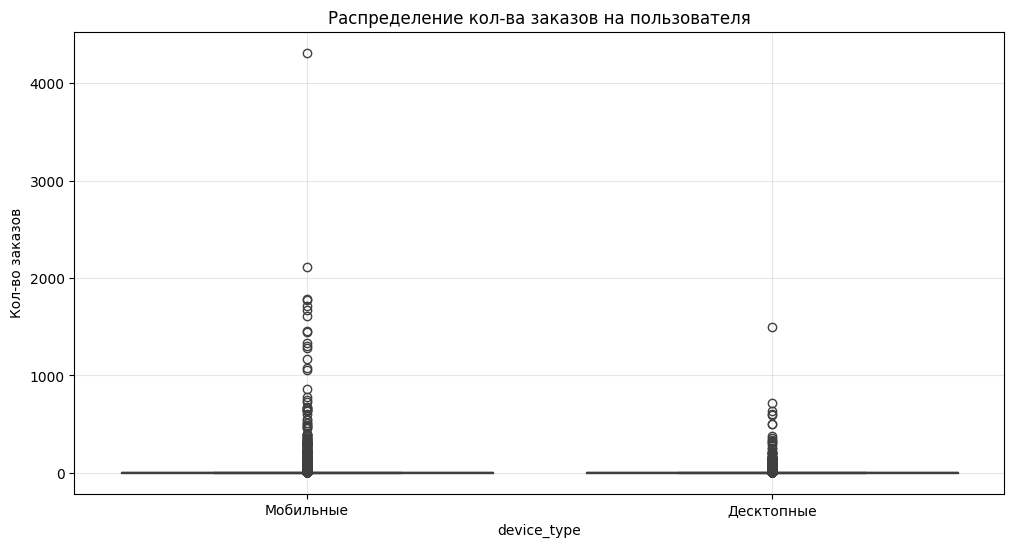

In [139]:
# Визуализация распределений заказов
fig, ax1 = plt.subplots(figsize=(12, 6))

# Боксплот
plot_data1 = pd.DataFrame({
    'device_type': ['Мобильные'] * len(mobile_orders_per_user) + 
                   ['Десктопные'] * len(desktop_orders_per_user),
    'orders_per_user': list(mobile_orders_per_user) + list(desktop_orders_per_user)
})
sns.boxplot(data=plot_data1, x='device_type', y='orders_per_user', 
            hue='device_type', legend=False, ax=ax1)
ax1.set_title('Распределение кол-ва заказов на пользователя')
ax1.set_ylabel('Кол-во заказов')
ax1.grid(True, alpha=0.3)

- В исключительных случаях кол-во заказов превышает 500.

In [140]:
# Проверка нормальности распределения
shapiro_mobile = stats.shapiro(mobile_orders_per_user)
shapiro_desktop = stats.shapiro(desktop_orders_per_user)
print(f"Тест Шапиро на нормальность:")
print(f"  Мобильные: W = {shapiro_mobile.statistic:.3f}, p = {shapiro_mobile.pvalue:.3e}")
print(f"  Десктопные: W = {shapiro_desktop.statistic:.3f}, p = {shapiro_desktop.pvalue:.3e}")

Тест Шапиро на нормальность:
  Мобильные: W = 0.078, p = 4.145e-123
  Десктопные: W = 0.125, p = 5.736e-92


In [141]:
# Проверка равенства дисперсий
levene_test = stats.levene(mobile_orders_per_user, desktop_orders_per_user)
print(f"Тест Левена на равенство дисперсий: F = {levene_test.statistic:.3f}, p = {levene_test.pvalue:.3e}")

Тест Левена на равенство дисперсий: F = 5.447, p = 1.962e-02


**Выбор статистического теста:**
- Распределения не являются нормальными для обоих тестов Шапиро.
- Используем непараметрический тест Манна-Уитни.

#### Запуск A/B теста

In [142]:
# Запускаем тест
mannwhitney_result = stats.mannwhitneyu(mobile_orders_per_user, desktop_orders_per_user, 
                                       alternative='greater')
print(f"U-значение = {mannwhitney_result.statistic:,.0f}")
print(f"p-value = {mannwhitney_result.pvalue:.3e}")

U-значение = 35,896,777
p-value = 2.132e-07


In [143]:
# Расччитаем размер эффекта
def cliffs_delta(x, y):
    """Расчёт размера эффекта Cliff's Delta"""
    n_x, n_y = len(x), len(y)
    comparisons = sum(1 for i in x for j in y if i > j) - sum(1 for i in x for j in y if i < j)
    return comparisons / (n_x * n_y)

effect_size_1 = cliffs_delta(mobile_orders_per_user.values, desktop_orders_per_user.values)
print(f"Размер эффекта = {effect_size_1:.3f}")

Размер эффекта = 0.047


In [144]:
# Интерпретация размера эффекта
def interpret_cliffs_delta(d):
    if abs(d) < 0.474: return "незначительный"
    else: return "большой"

print(f"Интерпретация размера эффекта: {interpret_cliffs_delta(effect_size_1)}")

Интерпретация размера эффекта: незначительный


#### Интерпетация результатов

In [145]:
print(f"p-value = {mannwhitney_result.pvalue:.3e}")
if mannwhitney_result.pvalue < 0.05:
    print("ОТВЕРГАЕМ H₀: Мобильные пользователи делают статистически больше заказов")
    print(f"Размер эффекта: {effect_size_1:.3f} ({interpret_cliffs_delta(effect_size_1)})")

p-value = 2.132e-07
ОТВЕРГАЕМ H₀: Мобильные пользователи делают статистически больше заказов
Размер эффекта: 0.047 (незначительный)


### Гипотеза 2: Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

**Формулировка гипотез:**
- Среднее время между заказами одинаково **H₀: μ_mobile_time = μ_desktop_time**
- Пользователи мобильного приложения делают заказы чаще **H₁: μ_mobile_time < μ_desktop_time**

#### Изучение данных и подготовка данных

In [146]:
# Функция для расчета среднего времени между заказами
def calculate_avg_time_between_orders(user_orders):
    if len(user_orders) < 2:
        return np.nan
    user_orders = user_orders.sort_values('created_ts_msk')
    time_diffs = (user_orders['created_ts_msk'].iloc[1:].reset_index(drop=True) - 
                 user_orders['created_ts_msk'].iloc[:-1].reset_index(drop=True)).dt.total_seconds() / 3600
    return time_diffs.mean()

# Расчет времени между заказами для каждого пользователя
mobile_time_between = []
for user_id, group in mobile_data.groupby('user_id'):
    if len(group) >= 2:
        avg_time = calculate_avg_time_between_orders(group)
        if not np.isnan(avg_time):
            mobile_time_between.append(avg_time)

desktop_time_between = []
for user_id, group in desktop_data.groupby('user_id'):
    if len(group) >= 2:
        avg_time = calculate_avg_time_between_orders(group)
        if not np.isnan(avg_time):
            desktop_time_between.append(avg_time)

mobile_time_between = pd.Series(mobile_time_between)
desktop_time_between = pd.Series(desktop_time_between)

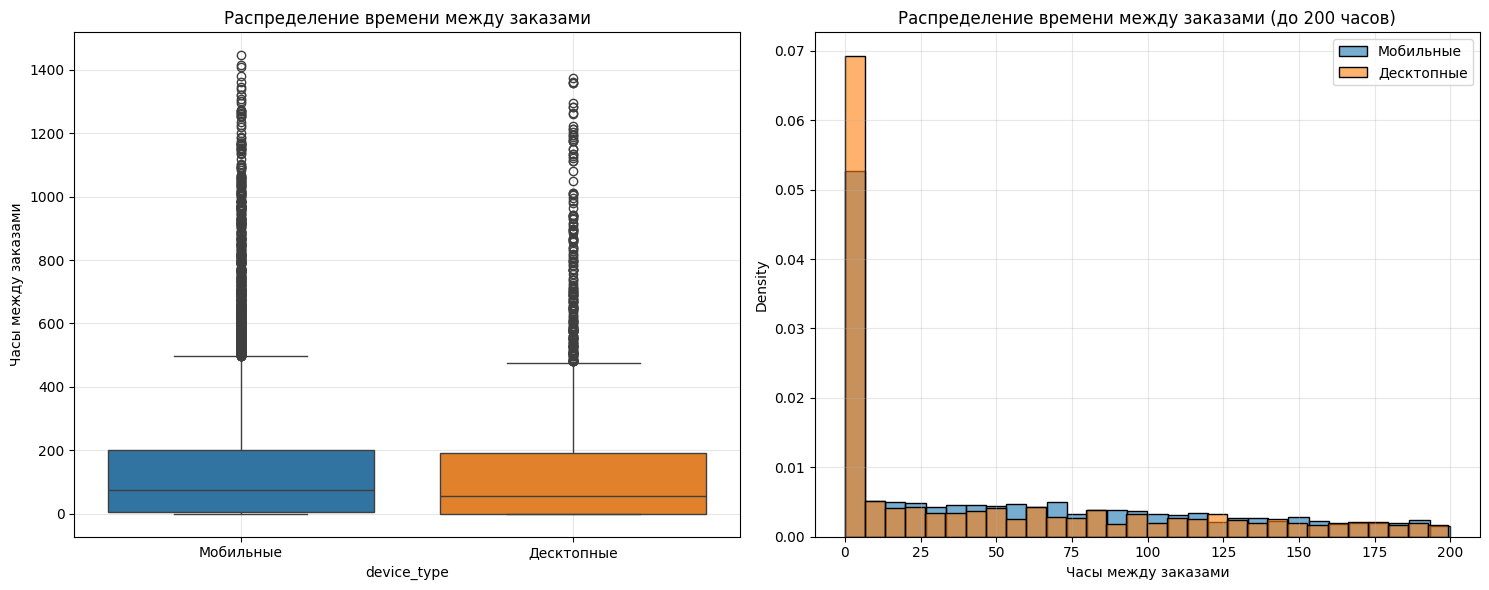

In [147]:
# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Боксплот
plot_data2 = pd.DataFrame({
    'device_type': ['Мобильные'] * len(mobile_time_between) + 
                   ['Десктопные'] * len(desktop_time_between),
    'time_between_orders': list(mobile_time_between) + list(desktop_time_between)
})
sns.boxplot(data=plot_data2, x='device_type', y='time_between_orders', 
            hue='device_type', legend=False, ax=ax1)
ax1.set_title('Распределение времени между заказами')
ax1.set_ylabel('Часы между заказами')
ax1.grid(True, alpha=0.3)

# Гистограмма
max_time = 200
filtered_mobile = mobile_time_between[mobile_time_between <= max_time]
filtered_desktop = desktop_time_between[desktop_time_between <= max_time]
sns.histplot(filtered_mobile, bins=30, alpha=0.6, label='Мобильные', ax=ax2, stat='density')
sns.histplot(filtered_desktop, bins=30, alpha=0.6, label='Десктопные', ax=ax2, stat='density')
ax2.set_title(f'Распределение времени между заказами (до {max_time} часов)')
ax2.set_xlabel('Часы между заказами')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Визуально, сильно выраженных отличий между типами устройств не наблюдается.

In [148]:
# Проверка нормальности распределения
shapiro_mobile_time = stats.shapiro(mobile_time_between)
shapiro_desktop_time = stats.shapiro(desktop_time_between)
print(f"\nТест Шапиро на нормальность:")
print(f"  Мобильные: W = {shapiro_mobile_time.statistic:.3f}, p = {shapiro_mobile_time.pvalue:.3e}")
print(f"  Десктопные: W = {shapiro_desktop_time.statistic:.3f}, p = {shapiro_desktop_time.pvalue:.3e}")


Тест Шапиро на нормальность:
  Мобильные: W = 0.718, p = 1.478e-79
  Десктопные: W = 0.687, p = 2.241e-57


In [149]:
# Проверка равенства дисперсий
levene_test = stats.levene(mobile_time_between, desktop_time_between)
print(f"Тест Левена на равенство дисперсий: F = {levene_test.statistic:.3f}, p = {levene_test.pvalue:.3e}")

Тест Левена на равенство дисперсий: F = 0.112, p = 7.373e-01


**Выбор статистического теста:**
- Распределения не являются нормальными для обоих тестов.
- Используем непараметрический тест Манна-Уитни.

#### Запуск A/B теста

In [150]:
# Запускаем тест
mannwhitney_time = stats.mannwhitneyu(mobile_time_between, desktop_time_between, 
                                     alternative='less')
print(f"U-Значения = {mannwhitney_time.statistic:,.0f}")
print(f"p-value = {mannwhitney_time.pvalue:.3e}")

U-Значения = 11,964,570
p-value = 1.000e+00


In [151]:
# Расччитаем размер эффекта
effect_size_2 = cliffs_delta(mobile_time_between.values, desktop_time_between.values)
print(f"Размер эффекта = {effect_size_2:.3f}")

Размер эффекта = 0.073


In [152]:
# Интерпретация размера эффекта
print(f"Интерпретация размера эффекта: {interpret_cliffs_delta(effect_size_2)}")

Интерпретация размера эффекта: незначительный


#### Интерпетация результатов

In [153]:
print(f"p-value = {mannwhitney_time.pvalue:.3e}")
if mannwhitney_time.pvalue < 0.05:
    print("ОТВЕРГАЕМ H₀: Мобильные пользователи делают заказы статистически значимо чаще")
    print(f"Размер эффекта: {effect_size_2:.3f} ({interpret_cliffs_delta(effect_size_2)})")
else:
    print("НЕ ОТВЕРГАЕМ H₀: Нет доказательств различий во времени между заказами")

p-value = 1.000e+00
НЕ ОТВЕРГАЕМ H₀: Нет доказательств различий во времени между заказами


### Выводы по результатам тестов

**Методология тестов:**
- Использованы непараметрические тесты Манна-Уитни из-за ненормальности распределений
- Уровень значимости α = `0.05`
- Односторонние альтернативные гипотезы
- Размер эффекта оценен с помощью Cliff Delta

**Практические выводы:**

- По результатам двух А/В тестов выявлено, что пользователи мобильного приложения делают больше заказов, но не обязательно чаще по времени.

**Рекомендация:**
- Cосредоточиться на увеличении лояльности пользователей мобильной версии.

## 5. Общий вывод и рекомендации

#### 1. Сезонная динамика

**Выводы:**
- Наблюдается **экспоненциальный рост** заказов на **200.9%** с июня по октябрь
- Осенние месяцы (сентябрь-октябрь) показали **на 47% больше заказов**, чем все летние месяцы вместе взятые

**Рекомендации:**
- **Разработать сезонную маркетинговую стратегию** с акцентом на осенний период
- **Оптимизировать операционные процессы** для обработки возросшего объема заказов
---
#### 2. Географическая концентрация

**Выводы:**
- Высокая **географическая концентрация**: 2 региона (Каменевский и Североярская область) генерируют **43.5%** всех мероприятий
- Топ-10 регионов охватывают **69.8%** рынка
- **Каменевский регион** доминирует с 26.3% долей рынка

**Рекомендации:**
- **Сфокусировать ресурсы** на ключевые регионы-лидеры
- **Разработать региональные стратегии** для топ-10 регионов
- **Исследовать потенциал** менее охваченных регионов для диверсификации
---
#### 3. Партнёрская сеть

**Выводы:**
- **Высокая концентрация** среди партнеров: топ-10 обрабатывают **90.3%** заказов
- **"Билеты без проблем"** - абсолютный лидер (20.5% заказов, 16.4% выручки)

**Рекомендации:**
- **Укрепить отношения** с ключевыми партнерами (топ-5)
- **Разработать программу лояльности** для топ-партнеров
- **Диверсифицировать партнерскую сеть** для снижения рисков
---
#### 4. Пользователи

**Выводы:**
- **Мобильные пользователи доминируют**:**79.6%** всех заказов
- Пользователи мобильного приложения **делают больше заказов**, но требуют работы над лояльностью

**Рекомендации:**
- **Приоритизировать развитие мобильной платформы**
- **Внедрить программу лояльности** для мобильных пользователей\
- **Разработать стратегию** для увеличения частоты покупок
---
#### 5. Ценовая стратегия и категории

**Выводы:**
- **Концерты** - наиболее доходная категория в оба сезона
- **Спорт** имеет самую низкую выручку с билета
- **Осенью рост цен** в категориях "выставки" и "стендап"
- **Театр и спорт** показали рост осенью

**Рекомендации:**
- **Увеличить продвижение** высокомаржинальных категорий
- **Создать пакетные предложения** для низкомаржинальных категорий
- **Исследовать потенциал** роста цен в перспективных категориях
---
#### 6. Аудитория по возрастам

**Выводы:**
- **Аудитория 16+** составляет **более 25%** всех заказов
- **Летом доля взрослой аудитории** еще выше

**Рекомендации:**
- **Разработать таргетированные кампании** для аудитории **16+**
- **Создать специальные предложения** для взрослой аудитории
- **Исследовать потребности** возрастных сегментов
---
#### 7. Общее повышение эффективности

**Выводы:**
- **Яркая недельная цикличность**: пики во вторник и выходные
- **Цены в выходные выше** на 10-15%
- **DAU показывает устойчивый рост**

**Рекомендации:**
- **Оптимизировать нагрузку** по дням недели
- **Внедрить динамическое ценообразование** для выходных дней
- **Планировать маркетинговые активности** на пиковые дни
- **Увеличить поддержку** в высоконагруженные периоды